In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_twitter_data.csv")
df.head()

,target,text,cleaned_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by ...,upset cant updat facebook text might cri resul...
2,0,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save rest go bound
3,0,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,"@nationwideclass no, it's not behaving at all....",no not behav im mad cant see


In [5]:
df.shape

(1592563, 3)

In [6]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, max_df=0.95)

In [7]:
X = vectorizer.fit_transform(df["cleaned_text"])
y = df["target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape

(1274050, 20000)

In [15]:
model_lr = LogisticRegression(max_iter=2000, C=2.0)
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [16]:
model_lr.score(X_test, y_test)

0.7998417647003419

In [17]:
print(classification_report(y_test, model_lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.81      0.78      0.80    158826
           1       0.79      0.82      0.80    159687

    accuracy                           0.80    318513
   macro avg       0.80      0.80      0.80    318513
weighted avg       0.80      0.80      0.80    318513



<Axes: >

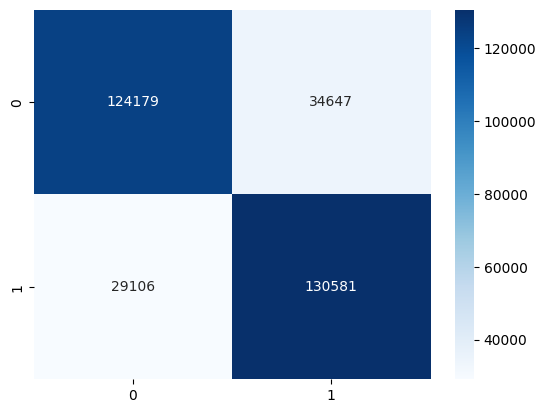

In [18]:
sns.heatmap(confusion_matrix(y_test, model_lr.predict(X_test)), annot=True, fmt="d", cmap="Blues")

In [ ]:
model_NB = MultinomialNB()
model_NB.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [11]:
model_NB.score(X_test, y_test)

0.7783387177289467

In [12]:
pred_NB = model_NB.predict(X_test)
print(classification_report(y_test, pred_NB))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78    158826
           1       0.78      0.78      0.78    159687

    accuracy                           0.78    318513
   macro avg       0.78      0.78      0.78    318513
weighted avg       0.78      0.78      0.78    318513



<Axes: >

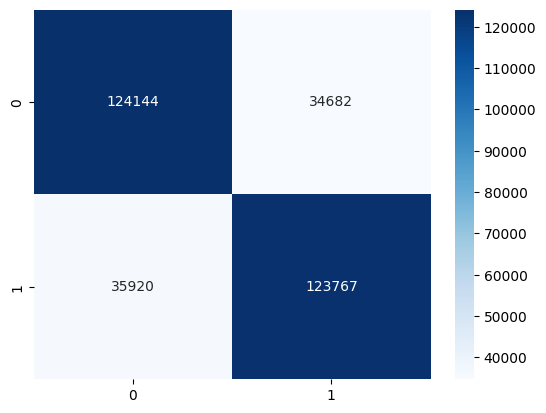

In [13]:
sns.heatmap(confusion_matrix(y_test, pred_NB), annot=True, fmt="d", cmap="Blues")

In [16]:
model_svc = LinearSVC()
model_svc.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [17]:
model_svc.score(X_test, y_test)

0.7986675583100219

In [20]:
pred_svc = model_svc.predict(X_test)
print(classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79    158826
           1       0.79      0.82      0.80    159687

    accuracy                           0.80    318513
   macro avg       0.80      0.80      0.80    318513
weighted avg       0.80      0.80      0.80    318513



<Axes: >

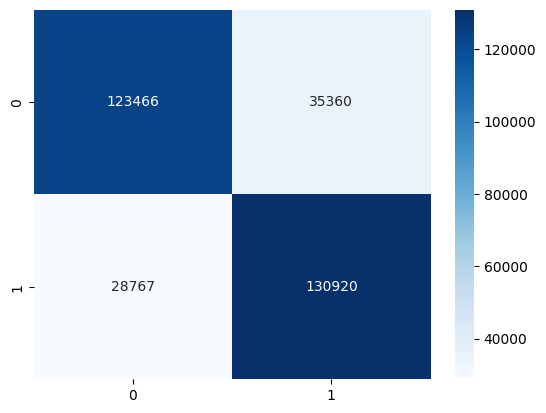

In [21]:
sns.heatmap(confusion_matrix(y_test, pred_svc), annot=True, fmt="d", cmap="Blues")

In [22]:
model_RFC = RandomForestClassifier(n_estimators=100, verbose=2, n_jobs=-1)
model_RFC.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed: 15.7min


building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 65.0min finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
model_RFC.score(X_test, y_test)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    2.3s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    9.7s finished


0.7877103917265543

In [24]:
pred = model_RFC.predict(X_test)
print(classification_report(y_test, pred))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    2.3s


              precision    recall  f1-score   support

           0       0.78      0.80      0.79    158826
           1       0.80      0.77      0.78    159687

    accuracy                           0.79    318513
   macro avg       0.79      0.79      0.79    318513
weighted avg       0.79      0.79      0.79    318513



[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    9.7s finished


<Axes: >

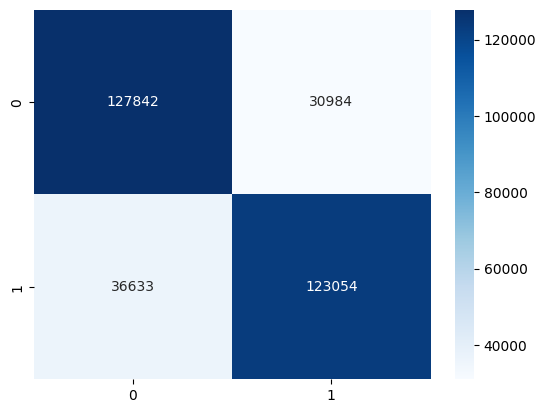

In [26]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues")